In [1]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload() # opens file picker
df = pd.read_csv(io.BytesIO(uploaded['housing_dirty_500.csv']))
print(df.head())

Saving housing_dirty_500.csv to housing_dirty_500.csv
        area rooms     price
0     4220.0   6.0  270600.0
1  4200 sqft     3   278,000
2     1970.0   7.0  107900.0
3     2890.0   6.0  ₦171,000
4      990.0   6.0   43500.0


In [2]:
import pandas as pd
import numpy as np

In [3]:
housing = pd.read_csv("housing_dirty_500.csv")

df.head()

,area,rooms,price
0,4220.0,6.0,270600.0
1,4200 sqft,3,"278,000"
2,1970.0,7.0,107900.0
3,2890.0,6.0,"₦171,000"
4,990.0,6.0,43500.0


In [4]:
housing.dtypes

,0
area,object
rooms,object
price,object


In [5]:
housing.isnull().sum()

,0
area,21
rooms,25
price,15


In [6]:
housing["area"] = housing["area"].fillna(housing["area"].mean())

housing["rooms"] = housing["rooms"].fillna(housing["rooms"].mean())

housing["price"] = housing["price"].fillna(housing["price"].mean())

TypeError: can only concatenate str (not "int") to str

In [7]:
# 1. Clean the 'price' column (removes $, commas, and spaces)
housing['price'] = housing['price'].astype(str).str.replace(r'[\$,\s]', '', regex=True)

In [8]:
# 2. Clean 'area' and 'rooms' (removes any text or non-numeric characters)
housing['area'] = housing['area'].astype(str).str.replace(r'[^\d.]', '', regex=True)
housing['rooms'] = housing['rooms'].astype(str).str.replace(r'[^\d.]', '', regex=True)

In [13]:
# 3. Convert all three columns to numbers
# errors='coerce' turns unparseable text into NaN (missing numbers)
housing['price'] = pd.to_numeric(housing['price'], errors='coerce')
housing['area'] = pd.to_numeric(housing['area'], errors='coerce')
housing['rooms'] = pd.to_numeric(housing['rooms'], errors='coerce')

In [14]:
housing.dtypes

,0
area,float64
rooms,float64
price,float64


In [15]:
housing.head(10)

,area,rooms,price
0,4220.0,6.0,270600.0
1,4200.0,3.0,278000.0
2,1970.0,7.0,107900.0
3,2890.0,6.0,NaN
4,990.0,6.0,43500.0
5,2370.0,2.0,141400.0
6,4400.0,3.0,285900.0
7,3010.0,3.0,180900.0
8,2540.0,9.0,NaN
9,3270.0,3.0,211600.0


In [17]:
import pandas as pd
import numpy as np

In [18]:
for col in ['area', 'rooms', 'price']:
    # 1. Strip the string structure and convert to standard numeric floats
    housing[col] = pd.to_numeric(housing[col], errors='coerce')

    # 2. Round down any floats to whole numbers and fill missing spots with np.nan
    housing[col] = np.floor(housing[col])

    # 3. Convert to the nullable Int64 type
    housing[col] = housing[col].astype('Int64')

In [19]:
housing = housing.copy()

In [26]:
housing.dtypes

,0
area,Int64
rooms,Int64
price,Int64


In [27]:
housing.isnull().sum()

,0
area,21
rooms,34
price,71


In [29]:
housing.describe()

,area,rooms,price
count,504.0,491.0,454.0
mean,3089.589286,4.576375,195771.312775
std,2962.236695,2.009105,222609.325554
min,720.0,1.0,0.0
25%,1727.5,3.0,102325.0
50%,2895.0,4.0,183200.0
75%,4050.0,6.0,261200.0
max,41428.0,9.0,3237349.0


In [34]:
# 1. Remove rows where price is 0
housing_cleaned = housing[housing['price'] > 0]

# 2. Filter out extreme outliers (adjust these numbers based on your dataset)
housing_cleaned = housing_cleaned[
    (housing_cleaned['area'] < 10000) &
    (housing_cleaned['price'] < 1000000)
]

In [36]:
housing_cleaned.head()

,area,rooms,price
0,4220,6,270600
1,4200,3,278000
2,1970,7,107900
4,990,6,43500
5,2370,2,141400


In [37]:
housing_cleaned.isnull().sum()

,0
area,0
rooms,29
price,0


In [38]:
# 1. Fill the missing values in the 'rooms' column with 4
housing_cleaned['rooms'] = housing_cleaned['rooms'].fillna(4)

In [39]:
housing_cleaned.isnull().sum()

,0
area,0
rooms,0
price,0


In [41]:
housing_cleaned.duplicated().sum()

np.int64(21)

In [42]:
housing_cleaned = housing_cleaned.drop_duplicates()

In [43]:
housing_cleaned.duplicated().sum()

np.int64(0)

In [44]:
housing_cleaned.describe()

,area,rooms,price
count,409.0,409.0,409.0
mean,2924.471883,4.459658,180014.180929
std,1280.763657,1.919702,90228.369546
min,720.0,1.0,15000.0
25%,1770.0,3.0,98900.0
50%,2970.0,4.0,184500.0
75%,4060.0,6.0,258900.0
max,5190.0,9.0,336400.0


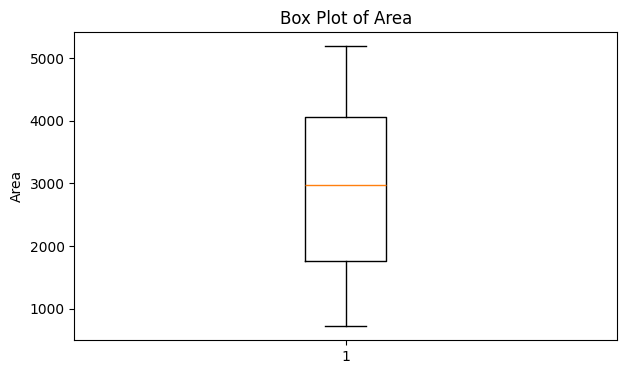

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.boxplot(housing_cleaned["area"].dropna())

plt.title("Box Plot of Area")
plt.ylabel("Area")

plt.show()

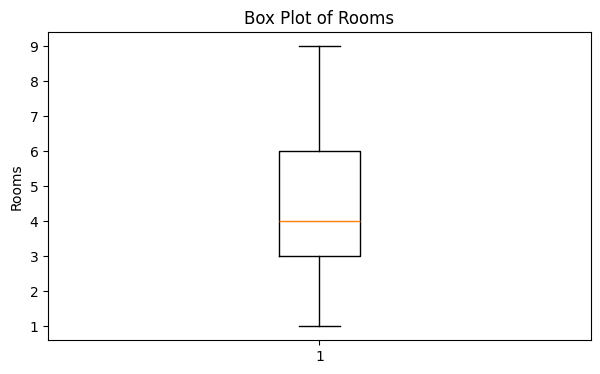

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.boxplot(housing_cleaned["rooms"].dropna())

plt.title("Box Plot of Rooms")
plt.ylabel("Rooms")

plt.show()

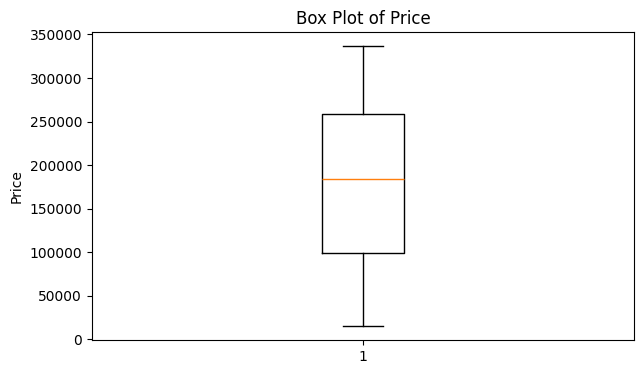

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.boxplot(housing_cleaned["price"].dropna())

plt.title("Box Plot of Price")
plt.ylabel("Price")

plt.show()

In [48]:
housing_cleaned.head(10)

,area,rooms,price
0,4220,6,270600
1,4200,3,278000
2,1970,7,107900
4,990,6,43500
5,2370,2,141400
6,4400,3,285900
7,3010,3,180900
9,3270,3,211600
10,1370,7,69100
11,3890,3,241200


In [51]:
housing_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 523
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    409 non-null    Int64
 1   rooms   409 non-null    Int64
 2   price   409 non-null    Int64
dtypes: Int64(3)
memory usage: 14.0 KB


In [56]:
housing_cleaned.shape

(409, 3)

In [57]:
housing_cleaned.to_csv("housing_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [58]:
housing_cleaned = pd.read_csv("housing_cleaned.csv")

In [59]:
housing_cleaned.head()

,area,rooms,price
0,4220,6,270600
1,4200,3,278000
2,1970,7,107900
3,990,6,43500
4,2370,2,141400


In [61]:
import pandas as pd

housing = pd.read_csv("housing_cleaned.csv")

housing.head()

,area,rooms,price
0,4220,6,270600
1,4200,3,278000
2,1970,7,107900
3,990,6,43500
4,2370,2,141400


In [62]:
housing_X = housing[["area", "rooms"]]

housing_Y = housing["price"]

housing_X.head()

,area,rooms
0,4220,6
1,4200,3
2,1970,7
3,990,6
4,2370,2


In [63]:
from sklearn.model_selection import train_test_split


In [65]:
housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
            housing_X,
            housing_Y,
            test_size=0.2,
            random_state=42
)

print("Training samples:", len(housing_X_train))
print("Testing samples:", len(housing_X_test))

Training samples: 327
Testing samples: 82


In [66]:
from sklearn.linear_model import LinearRegression


In [67]:
housing_model = LinearRegression()

housing_model.fit(housing_X_train, housing_y_train)

LinearRegression()

In [68]:
housing_predictions = housing_model.predict(housing_X_test)

housing_predictions


array([272320.13312307, 175545.5010388 ,  66913.44489869, 142031.31158524,
       289113.19731766, 225437.80196567, 324591.63429126, 143292.85064152,
       231275.28648259, 267185.35706991, 158193.60625169, 318195.31918181,
       131778.44037134, 297401.82101153, 190933.14830587, 317708.42752491,
       304213.08884226,  57634.35699859, 248699.12020532, 162194.04022739,
       233870.30353077,  74355.48225756, 224104.32397377, 169293.06380059,
        30228.726912  , 256644.73011353, 316231.07166177, 243149.39143087,
       252356.54039535,  80121.02783886,  68949.63135434, 307654.69222543,
       171473.12812749, 169995.77226435,  32264.91336765, 267888.06553366,
        38030.45894896,  54329.95912968,  52715.39775228,  75832.83812069,
        48012.25531282,  66138.79749931, 276176.68922753,  79346.38043949,
       271257.72998122,  49273.7943691 , 199509.52774222, 243852.09989463,
       290789.68909522, 322411.56996436, 200571.93088407,  71688.52627376,
       173509.31458315, 2

In [69]:
housing_comparison = pd.DataFrame({
    "Actual Price": housing_y_test.values,
    "Predicted Price": housing_predictions
})

housing_comparison

,Actual Price,Predicted Price
0,271300,272320.133123
1,169800,175545.501039
2,65100,66913.444899
3,141600,142031.311585
4,288800,289113.197318
...,...,...
77,26300,26228.292936
78,285900,284537.251857
79,257400,257275.499642
80,164900,160301.731643


In [70]:
from sklearn.metrics import mean_squared_error


In [72]:
housing_mse = mean_squared_error(
    housing_y_test,
    housing_predictions
)

(housing_y_test,
housing_predictions)

print("Housing MSE:", housing_mse)

Housing MSE: 1295097555.1919458


In [73]:
import matplotlib.pyplot as plt

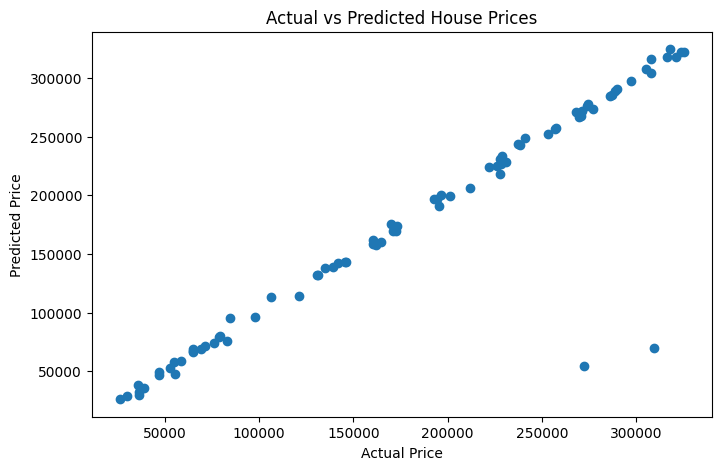

In [74]:
plt.figure(figsize=(8, 5))

plt.scatter(housing_y_test, housing_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()